# Notebook 15: Offline Stop-Policy Sensitivity And Evidence-Trajectory Diagnostics

This notebook analyzes the final Notebook `13` 49-case live run **without making API calls**.

It answers four concrete questions:

1. Which evidence fields were requested?
2. Which cases received more or less evidence, and how does that relate to correctness?
3. Did hard cases fail because they stopped early, asked poor questions, or stayed wrong despite many requests?
4. How sensitive is the selected Notebook `13` MLP stop rule to confidence/margin/entropy thresholds?

Important limitation: this is an offline replay analysis. It can test whether the existing live trajectory could have stopped earlier. It cannot know what would happen if a more conservative policy forced the LLM to continue after the original run already stopped.


## 1. Setup

The only required input is the saved Notebook `13` 49-case artifact directory.


In [1]:
from pathlib import Path
import json
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.metrics import f1_score
except Exception:
    f1_score = None

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
NOTEBOOK13_RUN = PROJECT_ROOT / "artifacts" / "sequential_hybrid_mlp_feedback" / "selected_stop_live_confirmation_49case_v1"
TRACE_PATH = NOTEBOOK13_RUN / "traces.jsonl"
PREDICTIONS_PATH = NOTEBOOK13_RUN / "predictions.csv"

ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "stop_policy_sensitivity" / "notebook13_49case_v1"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert TRACE_PATH.exists(), f"Missing traces: {TRACE_PATH}"
assert PREDICTIONS_PATH.exists(), f"Missing predictions: {PREDICTIONS_PATH}"

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

print("Notebook 13 artifact:", NOTEBOOK13_RUN)
print("Output artifact:", ARTIFACT_ROOT)


Notebook 13 artifact: /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/selected_stop_live_confirmation_49case_v1
Output artifact: /Users/bilalawan/claw/assignments/baseline_model/artifacts/stop_policy_sensitivity/notebook13_49case_v1


## 2. Load Notebook 13 Traces

Each trace row is one case. Each case contains turn-level states. Most turns reveal one evidence field; the final stop turn has no reveal payload. The one max-cap case has no explicit final stop turn, so we add a synthetic final state from the saved final outputs.


In [2]:
def safe_list(x):
    if isinstance(x, list):
        return x
    if x is None:
        return []
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []


def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

cases = load_jsonl(TRACE_PATH)
predictions = pd.read_csv(PREDICTIONS_PATH)
pred_by_case = predictions.set_index("case_id").to_dict("index")

print("cases:", len(cases))
print("prediction rows:", len(predictions))
print("total requests:", int(predictions["num_requests"].sum()))
print("mean requests:", predictions["num_requests"].mean())


cases: 49
prediction rows: 49
total requests: 323
mean requests: 6.591836734693878


## 3. Flatten Turn-Level States

For each turn, we record the current LLM prediction, MLP prediction, MLP confidence/margin/entropy, whether the true pathology is currently in the top-k, and whether the turn revealed evidence.


In [3]:
def topk_contains(items, truth, k=5):
    if not isinstance(items, list):
        return False
    return truth in items[:k]


def entropy_norm(probs):
    probs = np.array(probs, dtype=float)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return np.nan
    return float(-(probs * np.log(probs)).sum() / max(np.log(len(probs)), 1e-12))


def get_turn_state(case, turn, prior_request_count):
    true_path = case["true_pathology"]
    agent = turn.get("policy_response") or turn.get("agent_response") or {}
    mlp = turn.get("mlp_feedback") or {}
    det = turn.get("deterministic_state") or {}
    stop_signal = turn.get("stop_signal") or {}
    reveal = turn.get("reveal_payload") or None
    ranked = agent.get("ranked_differential") or []
    mlp_ranked = mlp.get("top_predictions") or []
    llm_pred = agent.get("predicted_pathology")
    mlp_pred = mlp.get("top1")
    agreement_pred = llm_pred if llm_pred == mlp_pred else llm_pred
    conservative_pred = llm_pred if llm_pred != mlp_pred else llm_pred
    num_before = prior_request_count
    request_made = reveal is not None
    requested_id = reveal.get("root_evidence_id") if reveal else agent.get("requested_evidence_id")
    return {
        "case_id": case["case_id"],
        "true_pathology": true_path,
        "turn_index": turn.get("turn_index"),
        "num_requests_before_turn": num_before,
        "request_made": bool(request_made),
        "requested_evidence_id": requested_id,
        "requested_question": reveal.get("question_en") if reveal else None,
        "reveal_status": reveal.get("status") if reveal else None,
        "reveal_summary": reveal.get("summary") if reveal else None,
        "llm_decision": agent.get("decision"),
        "llm_pred": llm_pred,
        "llm_ranked": ranked,
        "llm_confidence": agent.get("confidence"),
        "llm_correct": llm_pred == true_path,
        "llm_top3_correct": topk_contains(ranked, true_path, 3),
        "llm_top5_correct": topk_contains(ranked, true_path, 5),
        "mlp_pred": mlp_pred,
        "mlp_ranked": mlp_ranked,
        "mlp_confidence": mlp.get("confidence"),
        "mlp_margin": mlp.get("margin"),
        "mlp_entropy": mlp.get("entropy"),
        "mlp_stability_turns": mlp.get("stability_turns"),
        "mlp_revealed_root_count": mlp.get("revealed_root_count"),
        "mlp_correct": mlp_pred == true_path,
        "mlp_top3_correct": topk_contains(mlp_ranked, true_path, 3),
        "mlp_top5_correct": topk_contains(mlp_ranked, true_path, 5),
        "hybrid_pred": agreement_pred,
        "hybrid_correct": agreement_pred == true_path,
        "hybrid_top3_correct": topk_contains(ranked if llm_pred != mlp_pred else ranked, true_path, 3),
        "hybrid_top5_correct": topk_contains(ranked if llm_pred != mlp_pred else ranked, true_path, 5),
        "llm_mlp_agree": llm_pred == mlp_pred,
        "mlp_in_llm_top3": mlp_pred in ranked[:3] if isinstance(ranked, list) else False,
        "deterministic_top1": det.get("top_candidates", [[None]])[0][0] if det.get("top_candidates") else None,
        "deterministic_margin": det.get("margin"),
        "deterministic_unresolved_mass": det.get("unresolved_mass"),
        "stop_signal_level": stop_signal.get("level"),
        "stop_signal_reason": stop_signal.get("reason"),
        "selected_stop_rule_fired": stop_signal.get("selected_stop_rule_fired"),
        "top_shortlist_score": stop_signal.get("top_shortlist_score"),
        "policy_flags": turn.get("policy_flags", []),
        "error_flags": turn.get("error_flags", []),
    }

turn_rows = []
request_rows = []
for case in cases:
    request_count = 0
    case_turn_rows = []
    for turn in case.get("trace", []):
        row = get_turn_state(case, turn, request_count)
        case_turn_rows.append(row)
        if row["request_made"]:
            request_rows.append({
                "case_id": row["case_id"],
                "true_pathology": row["true_pathology"],
                "turn_index": row["turn_index"],
                "requested_evidence_id": row["requested_evidence_id"],
                "requested_question": row["requested_question"],
                "reveal_status": row["reveal_status"],
                "reveal_summary": row["reveal_summary"],
                "llm_pred_before_request": row["llm_pred"],
                "mlp_pred_before_request": row["mlp_pred"],
                "mlp_confidence_before_request": row["mlp_confidence"],
                "mlp_margin_before_request": row["mlp_margin"],
                "mlp_entropy_before_request": row["mlp_entropy"],
            })
            request_count += 1

    # The max-cap case has no final no-reveal stop turn in the trace. Add a synthetic final
    # state from predictions/final_mlp_feedback so replay metrics align with Notebook 13.
    observed_final_requests = int(pred_by_case[case["case_id"]]["num_requests"])
    has_final_no_reveal_state = any((not r["request_made"]) and int(r["num_requests_before_turn"]) == observed_final_requests for r in case_turn_rows)
    if not has_final_no_reveal_state and observed_final_requests == request_count:
        pred_rec = pred_by_case[case["case_id"]]
        mlp = case.get("final_mlp_feedback") or {}
        llm_ranked = safe_list(pred_rec.get("llm_ranked_differential")) or safe_list(pred_rec.get("ranked_differential"))
        mlp_ranked = safe_list(pred_rec.get("mlp_ranked_differential")) or mlp.get("top_predictions", [])
        synthetic = {
            "case_id": case["case_id"],
            "true_pathology": case["true_pathology"],
            "turn_index": (case_turn_rows[-1]["turn_index"] + 1) if case_turn_rows else 1,
            "num_requests_before_turn": observed_final_requests,
            "request_made": False,
            "requested_evidence_id": None,
            "requested_question": None,
            "reveal_status": None,
            "reveal_summary": None,
            "llm_decision": "stop",
            "llm_pred": pred_rec.get("llm_predicted_pathology") or pred_rec.get("predicted_pathology"),
            "llm_ranked": llm_ranked,
            "llm_confidence": pred_rec.get("llm_confidence"),
            "llm_correct": (pred_rec.get("llm_predicted_pathology") or pred_rec.get("predicted_pathology")) == case["true_pathology"],
            "llm_top3_correct": topk_contains(llm_ranked, case["true_pathology"], 3),
            "llm_top5_correct": topk_contains(llm_ranked, case["true_pathology"], 5),
            "mlp_pred": pred_rec.get("mlp_predicted_pathology") or mlp.get("top1"),
            "mlp_ranked": mlp_ranked,
            "mlp_confidence": mlp.get("confidence", pred_rec.get("final_mlp_confidence")),
            "mlp_margin": mlp.get("margin", pred_rec.get("final_mlp_margin")),
            "mlp_entropy": mlp.get("entropy", pred_rec.get("final_mlp_entropy")),
            "mlp_stability_turns": mlp.get("stability_turns", pred_rec.get("final_mlp_stability_turns")),
            "mlp_revealed_root_count": mlp.get("revealed_root_count", pred_rec.get("visible_root_count")),
            "mlp_correct": (pred_rec.get("mlp_predicted_pathology") or mlp.get("top1")) == case["true_pathology"],
            "mlp_top3_correct": topk_contains(mlp_ranked, case["true_pathology"], 3),
            "mlp_top5_correct": topk_contains(mlp_ranked, case["true_pathology"], 5),
            "hybrid_pred": pred_rec.get("agreement_hybrid_predicted_pathology") or pred_rec.get("predicted_pathology"),
            "hybrid_correct": (pred_rec.get("agreement_hybrid_predicted_pathology") or pred_rec.get("predicted_pathology")) == case["true_pathology"],
            "hybrid_top3_correct": topk_contains(safe_list(pred_rec.get("agreement_hybrid_ranked_differential")) or llm_ranked, case["true_pathology"], 3),
            "hybrid_top5_correct": topk_contains(safe_list(pred_rec.get("agreement_hybrid_ranked_differential")) or llm_ranked, case["true_pathology"], 5),
            "llm_mlp_agree": bool(pred_rec.get("llm_mlp_top1_agree")),
            "mlp_in_llm_top3": bool(pred_rec.get("mlp_in_llm_top3")),
            "deterministic_top1": pred_rec.get("deterministic_top1"),
            "deterministic_margin": pred_rec.get("deterministic_margin"),
            "deterministic_unresolved_mass": pred_rec.get("deterministic_unresolved_mass"),
            "stop_signal_level": "forced_cap_final_state",
            "stop_signal_reason": "Synthetic final state added after max-request cap so offline replay matches saved Notebook 13 final outputs.",
            "selected_stop_rule_fired": False,
            "top_shortlist_score": pred_rec.get("final_top_shortlist_score"),
            "policy_flags": [],
            "error_flags": [],
        }
        case_turn_rows.append(synthetic)

    turn_rows.extend(case_turn_rows)

turn_df = pd.DataFrame(turn_rows)
requests_df = pd.DataFrame(request_rows)

# For observed final states, use predictions.csv as the authoritative final output.
# Earlier turn states still come from the trace and remain valid early-stop counterfactuals.
for idx, row in turn_df.iterrows():
    pred_rec = pred_by_case.get(row["case_id"])
    if pred_rec is None:
        continue
    observed_final_requests = int(pred_rec["num_requests"])
    if (not bool(row["request_made"])) and int(row["num_requests_before_turn"]) == observed_final_requests:
        true_path = row["true_pathology"]
        llm_ranked = safe_list(pred_rec.get("llm_ranked_differential")) or safe_list(pred_rec.get("ranked_differential"))
        mlp_ranked = safe_list(pred_rec.get("mlp_ranked_differential"))
        hybrid_ranked = safe_list(pred_rec.get("agreement_hybrid_ranked_differential")) or llm_ranked
        llm_pred = pred_rec.get("llm_predicted_pathology") or pred_rec.get("predicted_pathology")
        mlp_pred = pred_rec.get("mlp_predicted_pathology")
        hybrid_pred = pred_rec.get("agreement_hybrid_predicted_pathology") or pred_rec.get("predicted_pathology")
        turn_df.at[idx, "llm_pred"] = llm_pred
        turn_df.at[idx, "llm_ranked"] = llm_ranked
        turn_df.at[idx, "llm_correct"] = llm_pred == true_path
        turn_df.at[idx, "llm_top3_correct"] = topk_contains(llm_ranked, true_path, 3)
        turn_df.at[idx, "llm_top5_correct"] = topk_contains(llm_ranked, true_path, 5)
        turn_df.at[idx, "mlp_pred"] = mlp_pred
        turn_df.at[idx, "mlp_ranked"] = mlp_ranked
        turn_df.at[idx, "mlp_correct"] = mlp_pred == true_path
        turn_df.at[idx, "mlp_top3_correct"] = topk_contains(mlp_ranked, true_path, 3)
        turn_df.at[idx, "mlp_top5_correct"] = topk_contains(mlp_ranked, true_path, 5)
        turn_df.at[idx, "hybrid_pred"] = hybrid_pred
        turn_df.at[idx, "hybrid_correct"] = hybrid_pred == true_path
        turn_df.at[idx, "hybrid_top3_correct"] = topk_contains(hybrid_ranked, true_path, 3)
        turn_df.at[idx, "hybrid_top5_correct"] = topk_contains(hybrid_ranked, true_path, 5)
        turn_df.at[idx, "llm_mlp_agree"] = bool(pred_rec.get("llm_mlp_top1_agree"))
        turn_df.at[idx, "mlp_in_llm_top3"] = bool(pred_rec.get("mlp_in_llm_top3"))

turn_df.to_csv(ARTIFACT_ROOT / "turn_level_states.csv", index=False)
requests_df.to_csv(ARTIFACT_ROOT / "requested_evidence_long.csv", index=False)

print("turn states:", turn_df.shape)
print("request rows:", requests_df.shape)
display(turn_df.head(3))


turn states: (372, 41)
request rows: (323, 12)


,case_id,true_pathology,turn_index,num_requests_before_turn,request_made,requested_evidence_id,requested_question,reveal_status,reveal_summary,llm_decision,llm_pred,llm_ranked,llm_confidence,llm_correct,llm_top3_correct,llm_top5_correct,mlp_pred,mlp_ranked,mlp_confidence,mlp_margin,mlp_entropy,mlp_stability_turns,mlp_revealed_root_count,mlp_correct,mlp_top3_correct,mlp_top5_correct,hybrid_pred,hybrid_correct,hybrid_top3_correct,hybrid_top5_correct,llm_mlp_agree,mlp_in_llm_top3,deterministic_top1,deterministic_margin,deterministic_unresolved_mass,stop_signal_level,stop_signal_reason,selected_stop_rule_fired,top_shortlist_score,policy_flags,error_flags
0,test:38475,Acute COPD exacerbation / infection,1,0,True,E_91,Do you have a fever (either felt or measured with a thermometer)?,absent,Do you have a fever (either felt or measured with a thermometer)? -> no,request,Bronchiolitis,"[Bronchiolitis, Bronchospasm / acute asthma exacerbation, Pulmonary neoplasm, Acute pulmonary edema, Myocarditis]",0.630,False,False,False,Bronchospasm / acute asthma exacerbation,"[Bronchospasm / acute asthma exacerbation, Acute COPD exacerbation / infection, Anemia, Bronchiectasis, Possible NSTEMI / STEMI]",0.088918,0.003594,0.829156,0,1,False,True,True,Bronchiolitis,False,False,False,False,True,Bronchiolitis,0.594797,0.370634,continue,"Selected MLP stop rule has not fired; continue if a shortlisted question is useful. Current MLP conf=0.089, margin=0.004, entropy=0.829, requests=0.",False,0.8578,[],[]
1,test:38475,Acute COPD exacerbation / infection,2,1,True,E_124,Do you have asthma or have you ever had to use a bronchodilator in the past?,absent,Do you have asthma or have you ever had to use a bronchodilator in the past? -> no,request,Bronchospasm / acute asthma exacerbation,"[Bronchospasm / acute asthma exacerbation, Pulmonary neoplasm, Acute pulmonary edema, Myocarditis, Myasthenia gravis]",0.087,False,False,False,Bronchospasm / acute asthma exacerbation,"[Bronchospasm / acute asthma exacerbation, Acute COPD exacerbation / infection, Anemia, Sarcoidosis, Atrial fibrillation]",0.087333,0.014989,0.817595,1,2,False,True,True,Bronchospasm / acute asthma exacerbation,False,False,False,True,True,Bronchospasm / acute asthma exacerbation,0.044229,0.769058,continue,"Selected MLP stop rule has not fired; continue if a shortlisted question is useful. Current MLP conf=0.087, margin=0.015, entropy=0.818, requests=1.",False,0.6436,[],[]
2,test:38475,Acute COPD exacerbation / infection,3,2,True,E_79,Do you smoke cigarettes?,absent,Do you smoke cigarettes? -> no,request,Pulmonary neoplasm,"[Pulmonary neoplasm, Acute pulmonary edema, Myocarditis, Myasthenia gravis, Acute COPD exacerbation / infection]",0.690,False,False,True,Acute COPD exacerbation / infection,"[Acute COPD exacerbation / infection, Anemia, Sarcoidosis, Possible NSTEMI / STEMI, Pericarditis]",0.111182,0.028540,0.812394,0,3,True,True,True,Pulmonary neoplasm,False,False,True,False,False,Pulmonary neoplasm,0.009785,0.783793,continue,"Selected MLP stop rule has not fired; continue if a shortlisted question is useful. Current MLP conf=0.111, margin=0.029, entropy=0.812, requests=2.",False,0.6985,[],[]


## 4. Which Evidence Was Requested?

This table and plot show the most common requested DDXPlus evidence fields in the final Notebook `13` 49-case run.


,requested_evidence_id,requested_question,count,present_count,absent_count,value_count,unique_cases
10,E_129,"Do you have any lesions, redness or problems on your skin that you believe are related to the condition you are consulting for?",21,3,18,0,21
21,E_151,Do you have swelling in one or more areas of your body?,20,1,19,0,20
38,E_201,Do you have a cough?,14,3,11,0,14
75,E_79,Do you smoke cigarettes?,13,4,9,0,13
78,E_91,Do you have a fever (either felt or measured with a thermometer)?,11,1,10,0,11
31,E_181,Do you have nasal congestion or a clear runny nose?,10,2,8,0,10
45,E_214,Have you noticed a wheezing sound when you exhale?,10,2,8,0,10
59,E_41,Have you been in contact with a person with similar symptoms in the past 2 weeks?,10,2,8,0,10
60,E_45,Have you been coughing up blood?,9,3,6,0,9
67,E_66,Are you experiencing shortness of breath or difficulty breathing in a significant way?,9,5,4,0,9


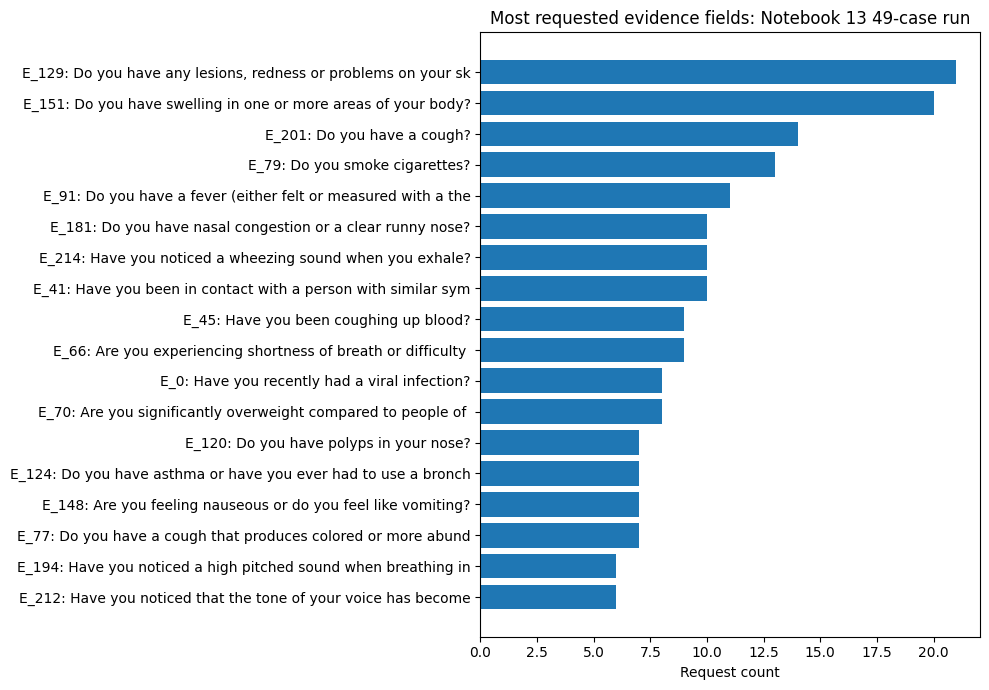

In [4]:
if not requests_df.empty:
    freq = (
        requests_df.groupby(["requested_evidence_id", "requested_question", "reveal_status"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    freq_by_field = (
        requests_df.groupby(["requested_evidence_id", "requested_question"], dropna=False)
        .agg(
            count=("case_id", "size"),
            present_count=("reveal_status", lambda s: int((s == "present").sum())),
            absent_count=("reveal_status", lambda s: int((s == "absent").sum())),
            value_count=("reveal_status", lambda s: int((s == "value").sum())),
            unique_cases=("case_id", "nunique"),
        )
        .reset_index()
        .sort_values(["count", "requested_evidence_id"], ascending=[False, True])
    )
else:
    freq = pd.DataFrame()
    freq_by_field = pd.DataFrame()

freq.to_csv(ARTIFACT_ROOT / "requested_evidence_frequency_by_status.csv", index=False)
freq_by_field.to_csv(ARTIFACT_ROOT / "requested_evidence_frequency.csv", index=False)

display(freq_by_field.head(20))

plt.figure(figsize=(10, 7))
plot_df = freq_by_field.head(18).copy()
if not plot_df.empty:
    labels = plot_df["requested_evidence_id"] + ": " + plot_df["requested_question"].str.slice(0, 55)
    plt.barh(labels[::-1], plot_df["count"][::-1])
    plt.xlabel("Request count")
    plt.title("Most requested evidence fields: Notebook 13 49-case run")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "requested_evidence_frequency.png", dpi=180)
    plt.show()


## 5. Which Cases Got More Or Less Evidence?

This section checks whether the model spent more evidence on hard cases, and whether errors are early-stop failures or long-trajectory failures.


,case_id,true_pathology,predicted_pathology,correct,num_requests,visible_root_count,stop_reason,stop_rule_fired,final_mlp_confidence,final_mlp_margin,final_mlp_entropy,llm_mlp_top1_agree,mlp_in_llm_top3
46,test:125508,Unstable angina,Anemia,False,2,3,agent_stop,False,0.911366,0.889112,0.127348,True,True
24,test:8666,Influenza,HIV (initial infection),False,3,4,agent_stop,False,0.908767,0.860277,0.101819,True,True
5,test:111176,Acute rhinosinusitis,Chronic rhinosinusitis,False,8,9,selected_mlp_stop,True,0.928670,0.887981,0.089106,True,True
33,test:62878,Pericarditis,Anemia,False,15,16,agent_stop,False,0.870966,0.830839,0.158602,True,True
18,test:81691,Croup,Anemia,False,19,20,agent_stop,False,0.835829,0.735497,0.171868,True,True
0,test:38475,Acute COPD exacerbation / infection,Myocarditis,False,24,25,max_requests_reached,False,0.498458,0.397677,0.472148,False,True
12,test:90978,Bronchiolitis,Bronchiolitis,True,0,1,agent_stop,False,0.824638,0.698369,0.166765,True,True
1,test:104857,Acute dystonic reactions,Acute dystonic reactions,True,1,2,selected_mlp_stop,True,0.931206,0.877838,0.085708,True,True
26,test:133888,Larygospasm,Larygospasm,True,1,2,selected_mlp_stop,True,0.957750,0.923153,0.050961,True,True
45,test:13402,URTI,URTI,True,1,2,selected_mlp_stop,True,0.940666,0.919032,0.082068,True,True


,correct,cases,mean_requests,median_requests,min_requests,max_requests,mean_mlp_confidence,mean_mlp_entropy
0,False,6,11.833333,11.5,2,24,0.825676,0.186815
1,True,43,5.860465,5.0,0,23,0.939704,0.062301


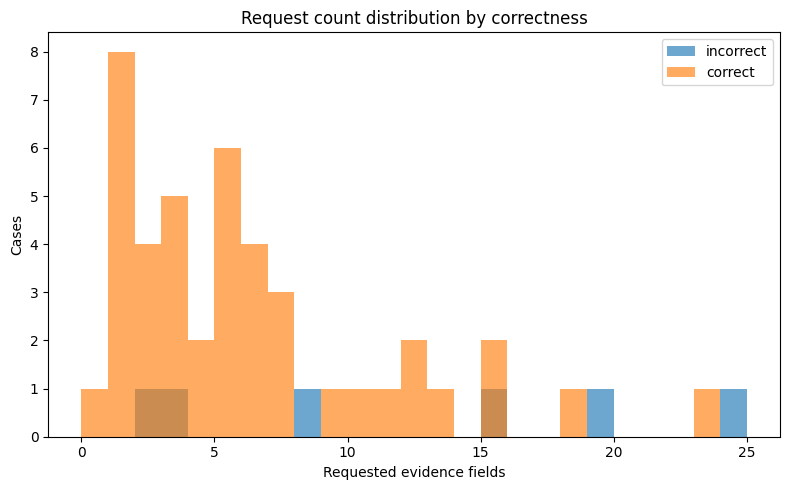

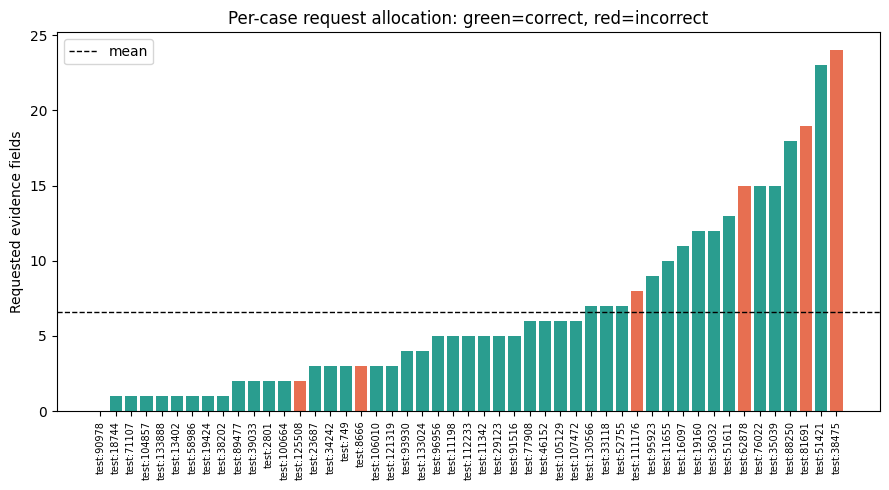

In [5]:
case_outcomes = predictions[[
    "case_id", "true_pathology", "predicted_pathology", "correct", "num_requests", "visible_root_count",
    "stop_reason", "stop_rule_fired", "final_mlp_confidence", "final_mlp_margin", "final_mlp_entropy",
    "llm_mlp_top1_agree", "mlp_in_llm_top3"
]].copy()
case_outcomes = case_outcomes.sort_values(["correct", "num_requests", "case_id"])
case_outcomes.to_csv(ARTIFACT_ROOT / "case_request_outcomes.csv", index=False)

display(case_outcomes)

summary_by_correct = case_outcomes.groupby("correct").agg(
    cases=("case_id", "size"),
    mean_requests=("num_requests", "mean"),
    median_requests=("num_requests", "median"),
    min_requests=("num_requests", "min"),
    max_requests=("num_requests", "max"),
    mean_mlp_confidence=("final_mlp_confidence", "mean"),
    mean_mlp_entropy=("final_mlp_entropy", "mean"),
).reset_index()
summary_by_correct.to_csv(ARTIFACT_ROOT / "request_summary_by_correctness.csv", index=False)
display(summary_by_correct)

plt.figure(figsize=(8, 5))
for flag, sub in case_outcomes.groupby("correct"):
    plt.hist(sub["num_requests"], bins=range(0, 26), alpha=0.65, label="correct" if flag else "incorrect")
plt.xlabel("Requested evidence fields")
plt.ylabel("Cases")
plt.title("Request count distribution by correctness")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "request_count_by_correctness.png", dpi=180)
plt.show()

plt.figure(figsize=(9, 5))
ordered = case_outcomes.sort_values("num_requests")
colors = ordered["correct"].map({True: "#2a9d8f", False: "#e76f51"})
plt.bar(range(len(ordered)), ordered["num_requests"], color=colors)
plt.axhline(ordered["num_requests"].mean(), color="black", linestyle="--", linewidth=1, label="mean")
plt.xticks(range(len(ordered)), ordered["case_id"], rotation=90, fontsize=7)
plt.ylabel("Requested evidence fields")
plt.title("Per-case request allocation: green=correct, red=incorrect")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "per_case_request_allocation.png", dpi=180)
plt.show()


## 6. Prediction Transitions Over Turns

This section quantifies whether additional evidence changed predictions from wrong to correct or from correct to wrong.

For each case and final head, we compare adjacent turn states:

- `wrong_to_correct`: later evidence helped that head
- `correct_to_wrong`: later evidence hurt that head
- `stays_correct`: stable correct prediction
- `stays_wrong`: stable wrong prediction


,head,wrong_to_correct,correct_to_wrong,stays_correct,stays_wrong
0,hybrid,40.0,11.0,79.0,193.0
1,llm,40.0,11.0,79.0,193.0
2,mlp,38.0,10.0,66.0,209.0


,case_id,true_pathology,head,num_states,first_prediction,last_prediction,first_correct,last_correct,ever_correct,first_correct_turn,wrong_to_correct,stays_correct,stays_wrong,correct_to_wrong
100,test:105129,Pulmonary neoplasm,hybrid,7,Possible NSTEMI / STEMI,Pulmonary neoplasm,False,True,True,4.0,2.0,0.0,3.0,1.0
116,test:19160,Possible NSTEMI / STEMI,hybrid,13,URTI,Possible NSTEMI / STEMI,False,True,True,3.0,2.0,8.0,1.0,1.0
121,test:33118,Acute otitis media,hybrid,8,Bronchiolitis,Acute otitis media,False,True,True,6.0,2.0,0.0,4.0,1.0
123,test:35039,Myocarditis,hybrid,16,Pericarditis,Myocarditis,False,True,True,4.0,2.0,1.0,11.0,1.0
128,test:46152,Cluster headache,hybrid,7,Viral pharyngitis,Cluster headache,False,True,True,2.0,2.0,2.0,1.0,1.0
129,test:51421,Chagas,hybrid,24,Bronchiolitis,Chagas,False,True,True,6.0,2.0,4.0,16.0,1.0
136,test:76022,Panic attack,hybrid,16,PSVT,Panic attack,False,True,True,3.0,2.0,1.0,11.0,1.0
122,test:34242,Guillain-Barré syndrome,hybrid,4,Guillain-Barré syndrome,Guillain-Barré syndrome,True,True,True,1.0,1.0,1.0,0.0,1.0
126,test:38475,Acute COPD exacerbation / infection,hybrid,25,Bronchiolitis,Myocarditis,False,False,True,20.0,1.0,0.0,22.0,1.0
138,test:81691,Croup,hybrid,20,Bronchiolitis,Anemia,False,False,True,5.0,1.0,0.0,17.0,1.0


<Figure size 800x500 with 0 Axes>

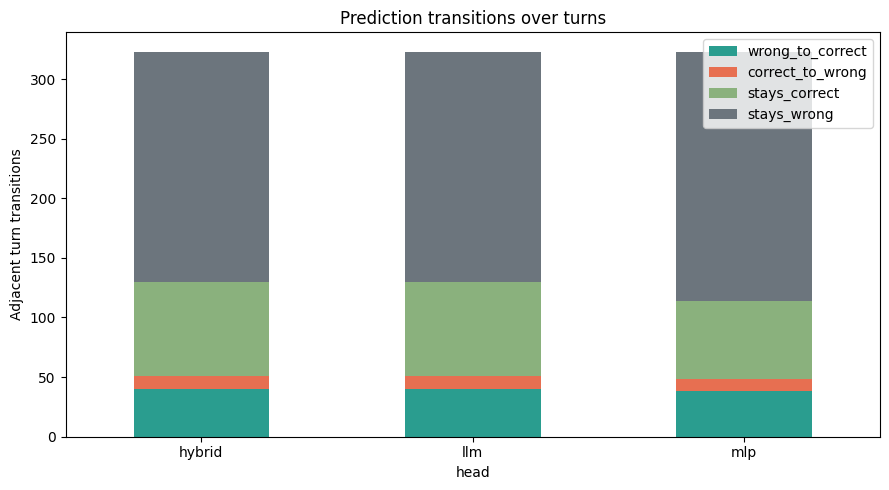

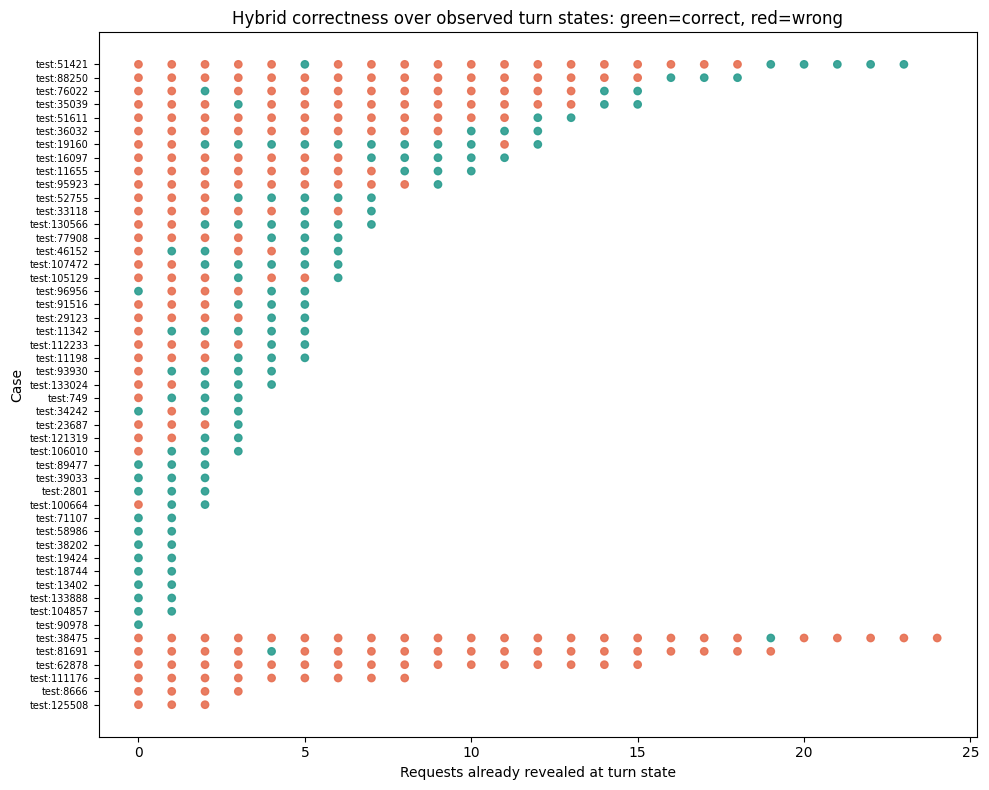

In [6]:
def summarize_transitions(df, head_prefix):
    pred_col = f"{head_prefix}_pred" if head_prefix != "hybrid" else "hybrid_pred"
    correct_col = f"{head_prefix}_correct" if head_prefix != "hybrid" else "hybrid_correct"
    rows = []
    for case_id, sub in df.sort_values(["case_id", "turn_index"]).groupby("case_id"):
        vals = sub[correct_col].astype(bool).tolist()
        preds = sub[pred_col].tolist()
        true_path = sub["true_pathology"].iloc[0]
        trans = Counter()
        for a, b in zip(vals, vals[1:]):
            if (not a) and b:
                trans["wrong_to_correct"] += 1
            elif a and (not b):
                trans["correct_to_wrong"] += 1
            elif a and b:
                trans["stays_correct"] += 1
            else:
                trans["stays_wrong"] += 1
        first_correct_turn = None
        for _, r in sub.iterrows():
            if bool(r[correct_col]):
                first_correct_turn = int(r["turn_index"])
                break
        rows.append({
            "case_id": case_id,
            "true_pathology": true_path,
            "head": head_prefix,
            "num_states": len(sub),
            "first_prediction": preds[0] if preds else None,
            "last_prediction": preds[-1] if preds else None,
            "first_correct": bool(vals[0]) if vals else False,
            "last_correct": bool(vals[-1]) if vals else False,
            "ever_correct": any(vals),
            "first_correct_turn": first_correct_turn,
            **trans,
        })
    return pd.DataFrame(rows).fillna({"wrong_to_correct":0, "correct_to_wrong":0, "stays_correct":0, "stays_wrong":0})

transition_parts = [summarize_transitions(turn_df, h) for h in ["llm", "mlp", "hybrid"]]
transition_df = pd.concat(transition_parts, ignore_index=True)
transition_df.to_csv(ARTIFACT_ROOT / "prediction_transition_summary.csv", index=False)

transition_totals = transition_df.groupby("head")[["wrong_to_correct", "correct_to_wrong", "stays_correct", "stays_wrong"]].sum().reset_index()
transition_totals.to_csv(ARTIFACT_ROOT / "prediction_transition_totals.csv", index=False)

display(transition_totals)
display(transition_df.sort_values(["head", "correct_to_wrong", "wrong_to_correct"], ascending=[True, False, False]).head(20))

plt.figure(figsize=(8, 5))
plot = transition_totals.set_index("head")[["wrong_to_correct", "correct_to_wrong", "stays_correct", "stays_wrong"]]
plot.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#2a9d8f", "#e76f51", "#8ab17d", "#6c757d"])
plt.ylabel("Adjacent turn transitions")
plt.title("Prediction transitions over turns")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "prediction_transition_totals.png", dpi=180)
plt.show()

# Correctness raster for hybrid final head over turn states.
raster_df = turn_df.copy()
raster_df["case_order"] = raster_df.groupby("case_id").ngroup()
case_order = case_outcomes.sort_values(["correct", "num_requests", "case_id"])["case_id"].tolist()
case_to_y = {c:i for i,c in enumerate(case_order)}
raster_df["y"] = raster_df["case_id"].map(case_to_y)
plt.figure(figsize=(10, 8))
colors = raster_df["hybrid_correct"].map({True: "#2a9d8f", False: "#e76f51"})
plt.scatter(raster_df["num_requests_before_turn"], raster_df["y"], c=colors, s=28, alpha=0.9)
plt.yticks(range(len(case_order)), case_order, fontsize=7)
plt.xlabel("Requests already revealed at turn state")
plt.ylabel("Case")
plt.title("Hybrid correctness over observed turn states: green=correct, red=wrong")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hybrid_turn_correctness_raster.png", dpi=180)
plt.show()


## 7. Hard-Case Timelines

The final 49-case errors are split into two broad types:

- early confident wrong stops
- long trajectories that still failed despite many requests

This table records what evidence was requested and how the LLM/MLP predictions evolved for those cases.


,case_id,true_pathology,turn_index,num_requests_before_turn,request_made,requested_evidence_id,requested_question,reveal_status,reveal_summary,llm_pred,llm_confidence,llm_correct,mlp_pred,mlp_confidence,mlp_margin,mlp_entropy,mlp_correct,llm_mlp_agree,stop_signal_level,selected_stop_rule_fired
42,test:111176,Acute rhinosinusitis,1,0,True,E_45,Have you been coughing up blood?,absent,Have you been coughing up blood? -> no,Tuberculosis,0.625,False,URTI,0.159544,0.049405,0.658021,False,False,continue,False
43,test:111176,Acute rhinosinusitis,2,1,True,E_77,Do you have a cough that produces colored or more abundant sputum than usual?,absent,Do you have a cough that produces colored or more abundant sputum than usual? -> no,Bronchitis,0.330,False,URTI,0.171971,0.028410,0.639098,False,False,continue,False
44,test:111176,Acute rhinosinusitis,3,2,True,E_120,Do you have polyps in your nose?,present,Do you have polyps in your nose? -> yes,Influenza,0.273,False,Allergic sinusitis,0.212922,0.017581,0.594072,False,False,continue,False
45,test:111176,Acute rhinosinusitis,4,3,True,E_209,Are your vaccinations up to date?,absent,Are your vaccinations up to date? -> no,Chronic rhinosinusitis,0.674,False,Chronic rhinosinusitis,0.674451,0.438711,0.259029,False,True,continue,False
46,test:111176,Acute rhinosinusitis,5,4,True,E_91,Do you have a fever (either felt or measured with a thermometer)?,absent,Do you have a fever (either felt or measured with a thermometer)? -> no,Chronic rhinosinusitis,0.682,False,Chronic rhinosinusitis,0.681933,0.553719,0.311055,False,True,continue,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,test:81691,Croup,20,19,False,None,None,None,None,Anemia,0.836,False,Anemia,0.835829,0.735497,0.171868,False,True,continue,False
198,test:8666,Influenza,1,0,True,E_214,Have you noticed a wheezing sound when you exhale?,absent,Have you noticed a wheezing sound when you exhale? -> no,Bronchiolitis,0.747,False,Viral pharyngitis,0.176453,0.014028,0.608533,False,False,continue,False
199,test:8666,Influenza,2,1,True,E_201,Do you have a cough?,absent,Do you have a cough? -> no,HIV (initial infection),0.480,False,Viral pharyngitis,0.194261,0.002136,0.593859,False,False,continue,False
200,test:8666,Influenza,3,2,True,E_129,"Do you have any lesions, redness or problems on your skin that you believe are related to the condition you are consulting for?",present,"Do you have any lesions, redness or problems on your skin that you believe are related to the condition you are consulting for? -> yes",HIV (initial infection),0.480,False,HIV (initial infection),0.300678,0.147260,0.560829,False,True,continue,False


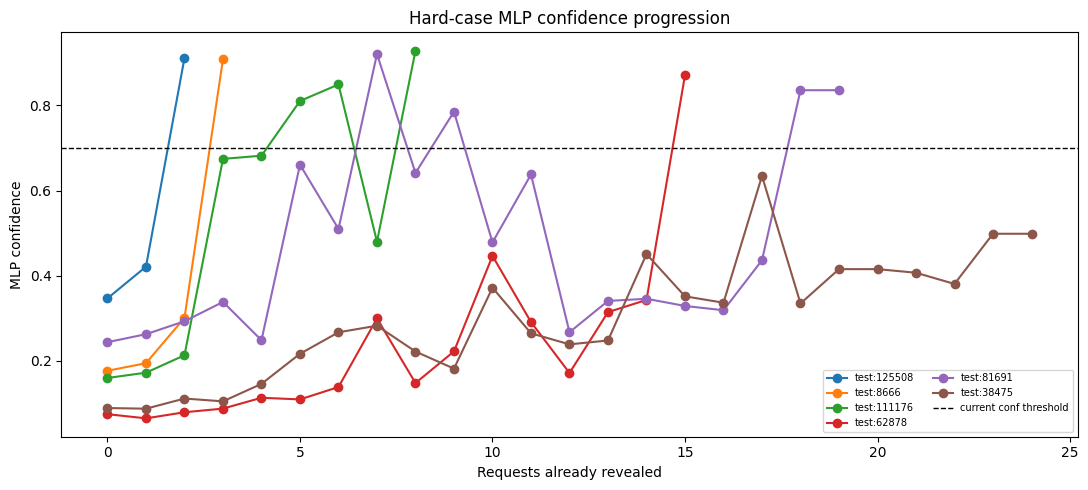

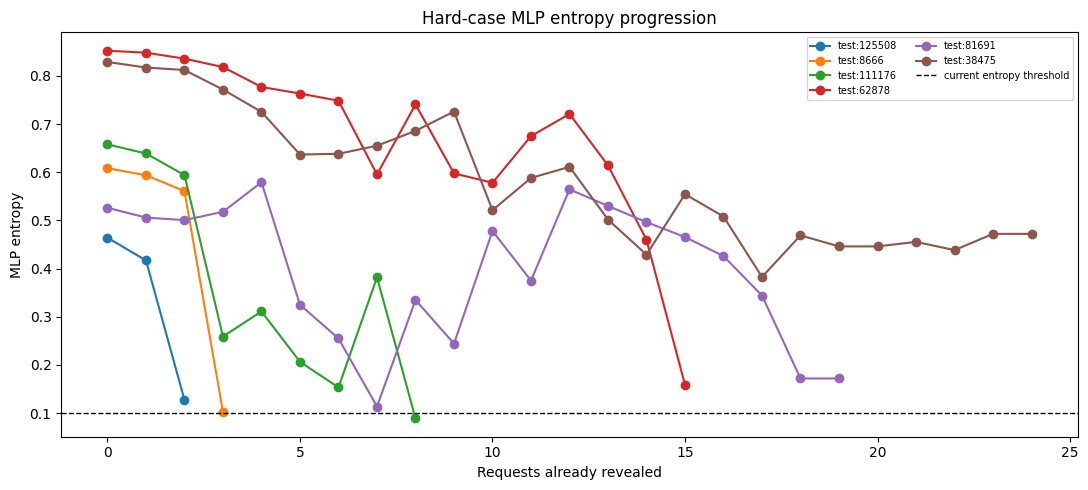

In [7]:
error_cases = case_outcomes.loc[~case_outcomes["correct"], "case_id"].tolist()
hard_timeline = turn_df[turn_df["case_id"].isin(error_cases)].copy()
hard_timeline = hard_timeline[[
    "case_id", "true_pathology", "turn_index", "num_requests_before_turn", "request_made",
    "requested_evidence_id", "requested_question", "reveal_status", "reveal_summary",
    "llm_pred", "llm_confidence", "llm_correct", "mlp_pred", "mlp_confidence", "mlp_margin", "mlp_entropy", "mlp_correct",
    "llm_mlp_agree", "stop_signal_level", "selected_stop_rule_fired"
]].sort_values(["case_id", "turn_index"])

hard_timeline.to_csv(ARTIFACT_ROOT / "hard_case_timelines.csv", index=False)
display(hard_timeline.head(80))

plt.figure(figsize=(11, 5))
for i, case_id in enumerate(error_cases):
    sub = hard_timeline[hard_timeline["case_id"] == case_id]
    plt.plot(sub["num_requests_before_turn"], sub["mlp_confidence"], marker="o", label=case_id)
plt.axhline(0.70, color="black", linestyle="--", linewidth=1, label="current conf threshold")
plt.xlabel("Requests already revealed")
plt.ylabel("MLP confidence")
plt.title("Hard-case MLP confidence progression")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hard_case_mlp_confidence_progression.png", dpi=180)
plt.show()

plt.figure(figsize=(11, 5))
for i, case_id in enumerate(error_cases):
    sub = hard_timeline[hard_timeline["case_id"] == case_id]
    plt.plot(sub["num_requests_before_turn"], sub["mlp_entropy"], marker="o", label=case_id)
plt.axhline(0.10, color="black", linestyle="--", linewidth=1, label="current entropy threshold")
plt.xlabel("Requests already revealed")
plt.ylabel("MLP entropy")
plt.title("Hard-case MLP entropy progression")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hard_case_mlp_entropy_progression.png", dpi=180)
plt.show()


## 8. Offline MLP Stop-Threshold Sweep

We sweep confidence, margin, entropy, and minimum-request thresholds using the observed Notebook `13` turn states.

Interpretation rules:

- If a threshold fires earlier than the original stop, this is a plausible offline early-stop counterfactual.
- If a threshold never fires before the original stop, we fall back to the observed final state. This does **not** prove that a stricter live policy would fail; it only means the saved trace has no future evidence after the original stop.
- Therefore this analysis is strongest for finding policies that stop earlier without losing accuracy.


In [8]:
# Candidate threshold grid. Includes the exact Notebook 13 rule.
CONF_THRESHOLDS = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
MARGIN_THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
ENTROPY_THRESHOLDS = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.30]
MIN_REQUESTS = [0, 1, 2, 3, 5, 8]

CURRENT_RULE = {
    "min_requests": 1,
    "confidence_min": 0.70,
    "margin_min": 0.20,
    "entropy_max": 0.10,
}


def hybrid_ranked_for_row(row):
    # The Notebook 13 agreement/conservative final heads use LLM when LLM and MLP disagree.
    ranked = row.get("llm_ranked")
    if isinstance(ranked, list):
        return ranked
    return []


def simulate_policy(rule, final_head="hybrid"):
    rows = []
    for case_id, sub in turn_df.sort_values(["case_id", "turn_index"]).groupby("case_id"):
        sub = sub.copy()
        stop_mask = (
            (sub["num_requests_before_turn"] >= rule["min_requests"]) &
            (sub["mlp_confidence"].fillna(-1) >= rule["confidence_min"]) &
            (sub["mlp_margin"].fillna(-1) >= rule["margin_min"]) &
            (sub["mlp_entropy"].fillna(999) <= rule["entropy_max"])
        )
        if stop_mask.any():
            stop_row = sub.loc[stop_mask].iloc[0]
            stop_source = "threshold_fired"
        else:
            # Fall back to last observed state. This is an offline limitation for stricter policies.
            stop_row = sub.iloc[-1]
            stop_source = "observed_final_fallback"

        true_path = stop_row["true_pathology"]
        llm_pred = stop_row["llm_pred"]
        mlp_pred = stop_row["mlp_pred"]
        llm_ranked = stop_row["llm_ranked"] if isinstance(stop_row["llm_ranked"], list) else []
        mlp_ranked = stop_row["mlp_ranked"] if isinstance(stop_row["mlp_ranked"], list) else []
        if final_head == "llm":
            pred = llm_pred
            ranked = llm_ranked
        elif final_head == "mlp":
            pred = mlp_pred
            ranked = mlp_ranked
        elif final_head in {"hybrid", "conservative_hybrid"}:
            # v1 official behavior: agreement uses agreement; disagreement falls back to LLM.
            pred = llm_pred if llm_pred != mlp_pred else llm_pred
            ranked = llm_ranked
        else:
            raise ValueError(final_head)
        rows.append({
            "case_id": case_id,
            "true_pathology": true_path,
            "final_head": final_head,
            "predicted_pathology": pred,
            "correct": pred == true_path,
            "top3_correct": topk_contains(ranked, true_path, 3),
            "top5_correct": topk_contains(ranked, true_path, 5),
            "stop_source": stop_source,
            "stop_turn_index": int(stop_row["turn_index"]),
            "num_requests": int(stop_row["num_requests_before_turn"]),
            "mlp_confidence": stop_row["mlp_confidence"],
            "mlp_margin": stop_row["mlp_margin"],
            "mlp_entropy": stop_row["mlp_entropy"],
            "llm_mlp_agree": bool(stop_row["llm_mlp_agree"]),
        })
    return pd.DataFrame(rows)


def macro_f1(y_true, y_pred):
    if f1_score is None:
        return np.nan
    return float(f1_score(y_true, y_pred, average="macro", zero_division=0))

sweep_rows = []
case_result_parts = []
for min_req in MIN_REQUESTS:
    for conf in CONF_THRESHOLDS:
        for margin in MARGIN_THRESHOLDS:
            for ent in ENTROPY_THRESHOLDS:
                rule = {"min_requests": min_req, "confidence_min": conf, "margin_min": margin, "entropy_max": ent}
                rule_name = f"min{min_req}_conf{conf:.2f}_margin{margin:.2f}_ent{ent:.2f}"
                for head in ["llm", "mlp", "hybrid"]:
                    res = simulate_policy(rule, final_head=head)
                    res["policy_name"] = rule_name
                    res["min_requests"] = min_req
                    res["confidence_min"] = conf
                    res["margin_min"] = margin
                    res["entropy_max"] = ent
                    if rule == CURRENT_RULE and head == "hybrid":
                        current_case_results = res.copy()
                    case_result_parts.append(res)
                    sweep_rows.append({
                        "policy_name": rule_name,
                        "final_head": head,
                        "min_requests": min_req,
                        "confidence_min": conf,
                        "margin_min": margin,
                        "entropy_max": ent,
                        "accuracy": float(res["correct"].mean()),
                        "correct_count": int(res["correct"].sum()),
                        "top3_accuracy": float(res["top3_correct"].mean()),
                        "top5_accuracy": float(res["top5_correct"].mean()),
                        "macro_f1": macro_f1(res["true_pathology"], res["predicted_pathology"]),
                        "mean_requests": float(res["num_requests"].mean()),
                        "median_requests": float(res["num_requests"].median()),
                        "threshold_fired_rate": float((res["stop_source"] == "threshold_fired").mean()),
                        "observed_final_fallback_count": int((res["stop_source"] == "observed_final_fallback").sum()),
                        "mean_mlp_confidence_at_stop": float(res["mlp_confidence"].mean()),
                        "mean_mlp_margin_at_stop": float(res["mlp_margin"].mean()),
                        "mean_mlp_entropy_at_stop": float(res["mlp_entropy"].mean()),
                    })

sweep = pd.DataFrame(sweep_rows)
case_policy_results = pd.concat(case_result_parts, ignore_index=True)

sweep.to_csv(ARTIFACT_ROOT / "threshold_sweep_summary.csv", index=False)
# This is large but useful for auditability, so keep it compressed.
case_policy_results.to_csv(ARTIFACT_ROOT / "threshold_policy_case_results.csv.gz", index=False, compression="gzip")

current_summary = sweep[
    (sweep["min_requests"] == CURRENT_RULE["min_requests"]) &
    (sweep["confidence_min"] == CURRENT_RULE["confidence_min"]) &
    (sweep["margin_min"] == CURRENT_RULE["margin_min"]) &
    (sweep["entropy_max"] == CURRENT_RULE["entropy_max"]) &
    (sweep["final_head"] == "hybrid")
].iloc[0].to_dict()

print("sweep rows:", len(sweep))
print("current rule summary:")
print(json.dumps(current_summary, indent=2))


sweep rows: 7938
current rule summary:
{
  "policy_name": "min1_conf0.70_margin0.20_ent0.10",
  "final_head": "hybrid",
  "min_requests": 1,
  "confidence_min": 0.7,
  "margin_min": 0.2,
  "entropy_max": 0.1,
  "accuracy": 0.8775510204081632,
  "correct_count": 43,
  "top3_accuracy": 0.9183673469387755,
  "top5_accuracy": 0.9387755102040817,
  "macro_f1": 0.8448979591836734,
  "mean_requests": 6.591836734693878,
  "median_requests": 5.0,
  "threshold_fired_rate": 0.7346938775510204,
  "observed_final_fallback_count": 13,
  "mean_mlp_confidence_at_stop": 0.9257417467175698,
  "mean_mlp_margin_at_stop": 0.8856422294351785,
  "mean_mlp_entropy_at_stop": 0.07754790808492117
}


## 9. Threshold Sweep Results

The frontier is computed within this offline replay setup. The most meaningful candidates are those that match or beat current accuracy while using fewer requests.


Current correct/requests: 43 6.591836734693878
Policies same-or-better than current accuracy under current mean request budget: 2758


,policy_name,final_head,min_requests,confidence_min,margin_min,entropy_max,accuracy,correct_count,top3_accuracy,top5_accuracy,macro_f1,mean_requests,median_requests,threshold_fired_rate,observed_final_fallback_count,mean_mlp_confidence_at_stop,mean_mlp_margin_at_stop,mean_mlp_entropy_at_stop
0,min0_conf0.55_margin0.10_ent0.05,llm,0,0.55,0.10,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
2,min0_conf0.55_margin0.10_ent0.05,hybrid,0,0.55,0.10,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
3,min0_conf0.55_margin0.10_ent0.08,llm,0,0.55,0.10,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
5,min0_conf0.55_margin0.10_ent0.08,hybrid,0,0.55,0.10,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
6,min0_conf0.55_margin0.10_ent0.10,llm,0,0.55,0.10,0.10,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.734694,13,0.925695,0.885571,0.07765
8,min0_conf0.55_margin0.10_ent0.10,hybrid,0,0.55,0.10,0.10,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.734694,13,0.925695,0.885571,0.07765
21,min0_conf0.55_margin0.15_ent0.05,llm,0,0.55,0.15,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
23,min0_conf0.55_margin0.15_ent0.05,hybrid,0,0.55,0.15,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
24,min0_conf0.55_margin0.15_ent0.08,llm,0,0.55,0.15,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
26,min0_conf0.55_margin0.15_ent0.08,hybrid,0,0.55,0.15,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765


Best policies under current budget:


,policy_name,final_head,min_requests,confidence_min,margin_min,entropy_max,accuracy,correct_count,top3_accuracy,top5_accuracy,macro_f1,mean_requests,median_requests,threshold_fired_rate,observed_final_fallback_count,mean_mlp_confidence_at_stop,mean_mlp_margin_at_stop,mean_mlp_entropy_at_stop
0,min0_conf0.55_margin0.10_ent0.05,llm,0,0.55,0.10,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
2,min0_conf0.55_margin0.10_ent0.05,hybrid,0,0.55,0.10,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
3,min0_conf0.55_margin0.10_ent0.08,llm,0,0.55,0.10,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
5,min0_conf0.55_margin0.10_ent0.08,hybrid,0,0.55,0.10,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
6,min0_conf0.55_margin0.10_ent0.10,llm,0,0.55,0.10,0.10,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.734694,13,0.925695,0.885571,0.07765
8,min0_conf0.55_margin0.10_ent0.10,hybrid,0,0.55,0.10,0.10,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.734694,13,0.925695,0.885571,0.07765
21,min0_conf0.55_margin0.15_ent0.05,llm,0,0.55,0.15,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
23,min0_conf0.55_margin0.15_ent0.05,hybrid,0,0.55,0.15,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
24,min0_conf0.55_margin0.15_ent0.08,llm,0,0.55,0.15,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
26,min0_conf0.55_margin0.15_ent0.08,hybrid,0,0.55,0.15,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765


Best accuracy policies overall in replay:


,policy_name,final_head,min_requests,confidence_min,margin_min,entropy_max,accuracy,correct_count,top3_accuracy,top5_accuracy,macro_f1,mean_requests,median_requests,threshold_fired_rate,observed_final_fallback_count,mean_mlp_confidence_at_stop,mean_mlp_margin_at_stop,mean_mlp_entropy_at_stop
0,min0_conf0.55_margin0.10_ent0.05,llm,0,0.55,0.10,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
2,min0_conf0.55_margin0.10_ent0.05,hybrid,0,0.55,0.10,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
3,min0_conf0.55_margin0.10_ent0.08,llm,0,0.55,0.10,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
5,min0_conf0.55_margin0.10_ent0.08,hybrid,0,0.55,0.10,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
6,min0_conf0.55_margin0.10_ent0.10,llm,0,0.55,0.10,0.10,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.734694,13,0.925695,0.885571,0.07765
8,min0_conf0.55_margin0.10_ent0.10,hybrid,0,0.55,0.10,0.10,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.734694,13,0.925695,0.885571,0.07765
21,min0_conf0.55_margin0.15_ent0.05,llm,0,0.55,0.15,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
23,min0_conf0.55_margin0.15_ent0.05,hybrid,0,0.55,0.15,0.05,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.510204,24,0.925695,0.885571,0.07765
24,min0_conf0.55_margin0.15_ent0.08,llm,0,0.55,0.15,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765
26,min0_conf0.55_margin0.15_ent0.08,hybrid,0,0.55,0.15,0.08,0.877551,43,0.918367,0.938776,0.844898,6.55102,5.0,0.612245,19,0.925695,0.885571,0.07765


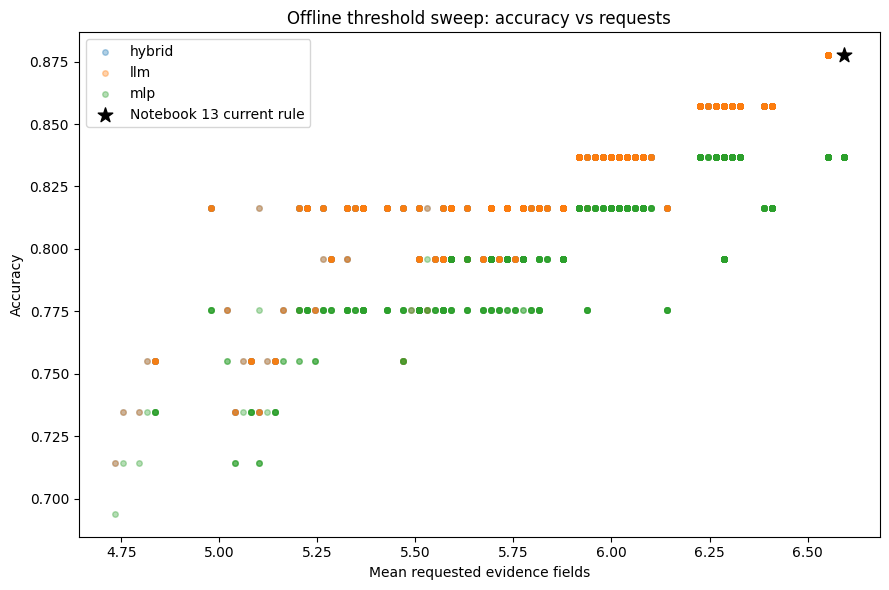

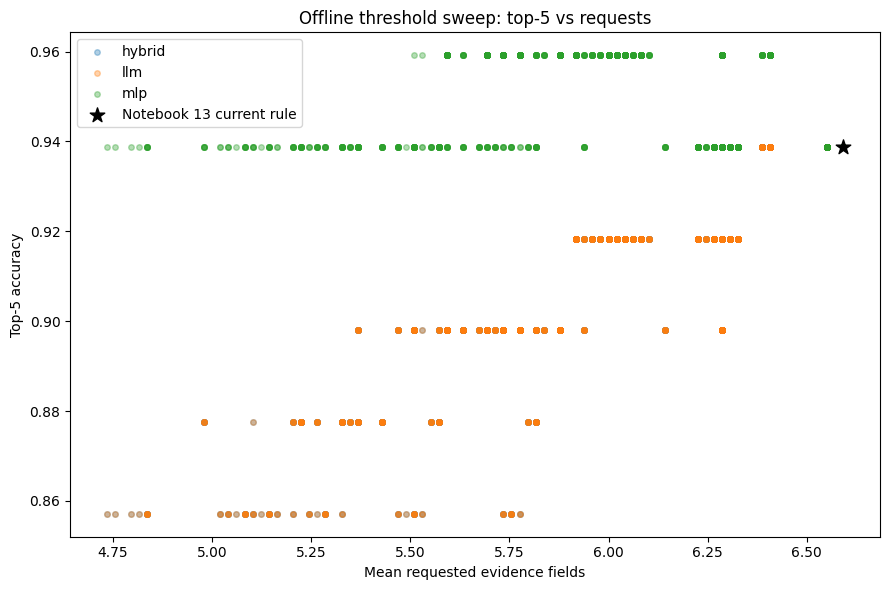

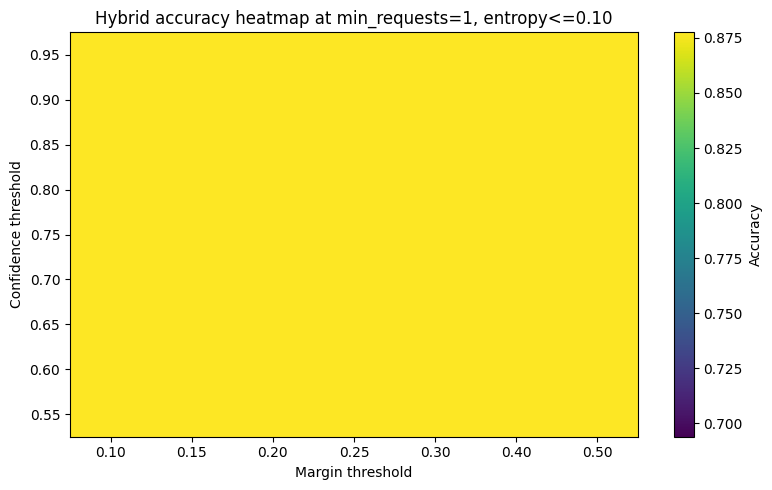

In [9]:
def pareto_frontier(df, acc_col="accuracy", cost_col="mean_requests"):
    d = df.sort_values([cost_col, acc_col], ascending=[True, False]).copy()
    best_acc = -1
    keep = []
    for _, r in d.iterrows():
        if r[acc_col] > best_acc + 1e-12:
            keep.append(True)
            best_acc = r[acc_col]
        else:
            keep.append(False)
    return d.loc[keep]

frontier = pareto_frontier(sweep[sweep["final_head"].isin(["hybrid", "llm", "mlp"])]).copy()
frontier.to_csv(ARTIFACT_ROOT / "threshold_policy_frontier.csv", index=False)

current_acc = current_summary["accuracy"]
current_mean_req = current_summary["mean_requests"]
current_correct = int(current_summary["correct_count"])

same_or_better = sweep[(sweep["correct_count"] >= current_correct) & (sweep["mean_requests"] <= current_mean_req + 1e-9)].copy()
same_or_better = same_or_better.sort_values(["mean_requests", "accuracy", "top5_accuracy"], ascending=[True, False, False])

best_under_current_budget = sweep[sweep["mean_requests"] <= current_mean_req + 1e-9].sort_values(
    ["accuracy", "top5_accuracy", "mean_requests"], ascending=[False, False, True]
).head(20)

best_accuracy = sweep.sort_values(["accuracy", "top5_accuracy", "mean_requests"], ascending=[False, False, True]).head(20)

same_or_better.to_csv(ARTIFACT_ROOT / "same_or_better_than_current_thresholds.csv", index=False)
best_under_current_budget.to_csv(ARTIFACT_ROOT / "best_policies_under_current_budget.csv", index=False)
best_accuracy.to_csv(ARTIFACT_ROOT / "best_accuracy_policies.csv", index=False)

print("Current correct/requests:", current_correct, current_mean_req)
print("Policies same-or-better than current accuracy under current mean request budget:", len(same_or_better))
display(same_or_better.head(20))
print("Best policies under current budget:")
display(best_under_current_budget)
print("Best accuracy policies overall in replay:")
display(best_accuracy)

plt.figure(figsize=(9, 6))
for head, sub in sweep.groupby("final_head"):
    plt.scatter(sub["mean_requests"], sub["accuracy"], s=16, alpha=0.35, label=head)
plt.scatter([current_mean_req], [current_acc], s=120, marker="*", color="black", label="Notebook 13 current rule")
plt.xlabel("Mean requested evidence fields")
plt.ylabel("Accuracy")
plt.title("Offline threshold sweep: accuracy vs requests")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_sweep_accuracy_vs_requests.png", dpi=180)
plt.show()

plt.figure(figsize=(9, 6))
for head, sub in sweep.groupby("final_head"):
    plt.scatter(sub["mean_requests"], sub["top5_accuracy"], s=16, alpha=0.35, label=head)
plt.scatter([current_mean_req], [current_summary["top5_accuracy"]], s=120, marker="*", color="black", label="Notebook 13 current rule")
plt.xlabel("Mean requested evidence fields")
plt.ylabel("Top-5 accuracy")
plt.title("Offline threshold sweep: top-5 vs requests")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_sweep_top5_vs_requests.png", dpi=180)
plt.show()

# Heatmap for the current min_requests and entropy threshold, hybrid head.
heat = sweep[(sweep["final_head"] == "hybrid") & (sweep["min_requests"] == 1) & (sweep["entropy_max"] == 0.10)].copy()
if not heat.empty:
    pivot = heat.pivot_table(index="confidence_min", columns="margin_min", values="accuracy", aggfunc="max")
    plt.figure(figsize=(8, 5))
    im = plt.imshow(pivot.values, aspect="auto", origin="lower", vmin=sweep["accuracy"].min(), vmax=sweep["accuracy"].max())
    plt.colorbar(im, label="Accuracy")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [f"{x:.2f}" for x in pivot.index])
    plt.xlabel("Margin threshold")
    plt.ylabel("Confidence threshold")
    plt.title("Hybrid accuracy heatmap at min_requests=1, entropy<=0.10")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "threshold_heatmap_conf_margin_entropy010.png", dpi=180)
    plt.show()


## 10. Case-Level Differences From Current Rule

If a candidate threshold matches current accuracy with fewer requests, this section shows which cases change.


{
  "policy_name": "min0_conf0.55_margin0.10_ent0.05",
  "final_head": "llm",
  "min_requests": 0,
  "confidence_min": 0.55,
  "margin_min": 0.1,
  "entropy_max": 0.05,
  "accuracy": 0.8775510204081632,
  "correct_count": 43,
  "top5_accuracy": 0.9387755102040817,
  "mean_requests": 6.551020408163265,
  "selection_logic": "lowest mean requests among policies with current-or-better correct count under current request budget",
  "offline_replay_caveat": "Can test earlier stopping on observed traces; cannot validate stricter continuation after the original live stop."
}


,case_id,true_pathology,current_predicted_pathology,current_correct,current_top5_correct,current_num_requests,current_stop_source,selected_predicted_pathology,selected_correct,selected_top5_correct,selected_num_requests,selected_stop_source,request_delta_selected_minus_current,correctness_change
17,test:18744,Anemia,Anemia,True,True,1,threshold_fired,Anemia,True,True,0,threshold_fired,-1,both_correct
19,test:19424,Whooping cough,Whooping cough,True,True,1,threshold_fired,Whooping cough,True,True,0,threshold_fired,-1,both_correct
0,test:100664,Myasthenia gravis,Myasthenia gravis,True,True,2,threshold_fired,Myasthenia gravis,True,True,2,threshold_fired,0,both_correct
1,test:104857,Acute dystonic reactions,Acute dystonic reactions,True,True,1,threshold_fired,Acute dystonic reactions,True,True,1,observed_final_fallback,0,both_correct
2,test:105129,Pulmonary neoplasm,Pulmonary neoplasm,True,True,6,threshold_fired,Pulmonary neoplasm,True,True,6,threshold_fired,0,both_correct
3,test:106010,HIV (initial infection),HIV (initial infection),True,True,3,threshold_fired,HIV (initial infection),True,True,3,threshold_fired,0,both_correct
4,test:107472,Tuberculosis,Tuberculosis,True,True,6,threshold_fired,Tuberculosis,True,True,6,threshold_fired,0,both_correct
6,test:11198,Boerhaave,Boerhaave,True,True,5,threshold_fired,Boerhaave,True,True,5,threshold_fired,0,both_correct
7,test:112233,Bronchiectasis,Bronchiectasis,True,True,5,threshold_fired,Bronchiectasis,True,True,5,threshold_fired,0,both_correct
8,test:11342,Atrial fibrillation,Atrial fibrillation,True,True,5,threshold_fired,Atrial fibrillation,True,True,5,threshold_fired,0,both_correct


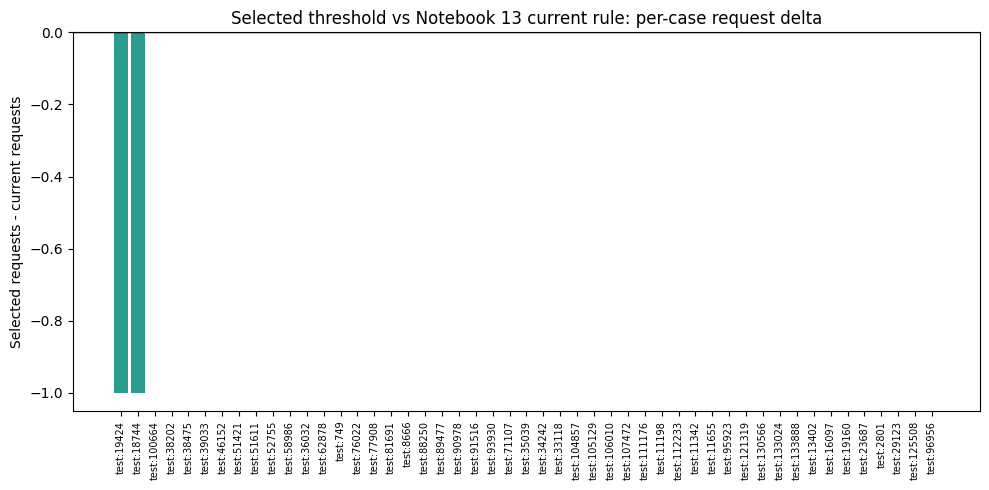

In [10]:
if not same_or_better.empty:
    selected = same_or_better.iloc[0].to_dict()
else:
    selected = best_under_current_budget.iloc[0].to_dict()

selected_rule = {
    "policy_name": selected["policy_name"],
    "final_head": selected["final_head"],
    "min_requests": int(selected["min_requests"]),
    "confidence_min": float(selected["confidence_min"]),
    "margin_min": float(selected["margin_min"]),
    "entropy_max": float(selected["entropy_max"]),
    "accuracy": float(selected["accuracy"]),
    "correct_count": int(selected["correct_count"]),
    "top5_accuracy": float(selected["top5_accuracy"]),
    "mean_requests": float(selected["mean_requests"]),
    "selection_logic": "lowest mean requests among policies with current-or-better correct count under current request budget" if not same_or_better.empty else "best accuracy under current request budget; no policy matched current accuracy",
    "offline_replay_caveat": "Can test earlier stopping on observed traces; cannot validate stricter continuation after the original live stop.",
}

with (ARTIFACT_ROOT / "selected_threshold_policy.json").open("w", encoding="utf-8") as f:
    json.dump(selected_rule, f, indent=2)

selected_cases = case_policy_results[
    (case_policy_results["policy_name"] == selected_rule["policy_name"]) &
    (case_policy_results["final_head"] == selected_rule["final_head"])
].copy()
current_cases = current_case_results.copy()
current_cases = current_cases.rename(columns={
    "predicted_pathology": "current_predicted_pathology",
    "correct": "current_correct",
    "top5_correct": "current_top5_correct",
    "num_requests": "current_num_requests",
    "stop_source": "current_stop_source",
})
selected_cases = selected_cases.rename(columns={
    "predicted_pathology": "selected_predicted_pathology",
    "correct": "selected_correct",
    "top5_correct": "selected_top5_correct",
    "num_requests": "selected_num_requests",
    "stop_source": "selected_stop_source",
})
compare = current_cases[["case_id", "true_pathology", "current_predicted_pathology", "current_correct", "current_top5_correct", "current_num_requests", "current_stop_source"]].merge(
    selected_cases[["case_id", "selected_predicted_pathology", "selected_correct", "selected_top5_correct", "selected_num_requests", "selected_stop_source"]],
    on="case_id", how="left"
)
compare["request_delta_selected_minus_current"] = compare["selected_num_requests"] - compare["current_num_requests"]
compare["correctness_change"] = np.select(
    [compare["current_correct"] & compare["selected_correct"],
     compare["current_correct"] & ~compare["selected_correct"],
     ~compare["current_correct"] & compare["selected_correct"],
     ~compare["current_correct"] & ~compare["selected_correct"]],
    ["both_correct", "current_only_correct", "selected_only_correct", "both_wrong"],
    default="unknown"
)
compare.to_csv(ARTIFACT_ROOT / "selected_vs_current_case_comparison.csv", index=False)

print(json.dumps(selected_rule, indent=2))
display(compare.sort_values(["correctness_change", "request_delta_selected_minus_current", "case_id"]))

plt.figure(figsize=(10, 5))
plot_df = compare.sort_values("request_delta_selected_minus_current")
colors = plot_df["correctness_change"].map({
    "both_correct": "#2a9d8f",
    "current_only_correct": "#e76f51",
    "selected_only_correct": "#457b9d",
    "both_wrong": "#6c757d",
})
plt.bar(range(len(plot_df)), plot_df["request_delta_selected_minus_current"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(range(len(plot_df)), plot_df["case_id"], rotation=90, fontsize=7)
plt.ylabel("Selected requests - current requests")
plt.title("Selected threshold vs Notebook 13 current rule: per-case request delta")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "selected_vs_current_request_delta.png", dpi=180)
plt.show()


## 11. Interpretation Summary

This cell writes a compact JSON summary for downstream reports.


In [11]:
interpretation = {
    "source_run": str(NOTEBOOK13_RUN),
    "num_cases": int(len(predictions)),
    "num_turn_states": int(len(turn_df)),
    "num_requested_evidence_rows": int(len(requests_df)),
    "current_rule": current_summary,
    "selected_offline_threshold_policy": selected_rule,
    "transition_totals": transition_totals.to_dict(orient="records"),
    "request_summary_by_correctness": summary_by_correct.to_dict(orient="records"),
    "error_cases": case_outcomes.loc[~case_outcomes["correct"], ["case_id", "true_pathology", "predicted_pathology", "num_requests", "stop_reason", "final_mlp_confidence", "final_mlp_entropy"]].to_dict(orient="records"),
    "caveats": [
        "Offline analysis can evaluate earlier stops on observed trajectories.",
        "Offline analysis cannot know what evidence would be acquired if a stricter policy continued after the original live stop.",
        "Mean requests alone is not the causal variable; evidence identity and stop timing matter.",
    ],
}
with (ARTIFACT_ROOT / "analysis_summary.json").open("w", encoding="utf-8") as f:
    json.dump(interpretation, f, indent=2)

print(json.dumps(interpretation, indent=2)[:5000])
print("\nSaved artifacts to", ARTIFACT_ROOT)


{
  "source_run": "/Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_hybrid_mlp_feedback/selected_stop_live_confirmation_49case_v1",
  "num_cases": 49,
  "num_turn_states": 372,
  "num_requested_evidence_rows": 323,
  "current_rule": {
    "policy_name": "min1_conf0.70_margin0.20_ent0.10",
    "final_head": "hybrid",
    "min_requests": 1,
    "confidence_min": 0.7,
    "margin_min": 0.2,
    "entropy_max": 0.1,
    "accuracy": 0.8775510204081632,
    "correct_count": 43,
    "top3_accuracy": 0.9183673469387755,
    "top5_accuracy": 0.9387755102040817,
    "macro_f1": 0.8448979591836734,
    "mean_requests": 6.591836734693878,
    "median_requests": 5.0,
    "threshold_fired_rate": 0.7346938775510204,
    "observed_final_fallback_count": 13,
    "mean_mlp_confidence_at_stop": 0.9257417467175698,
    "mean_mlp_margin_at_stop": 0.8856422294351785,
    "mean_mlp_entropy_at_stop": 0.07754790808492117
  },
  "selected_offline_threshold_policy": {
    "policy_name": "min0

## 12. Key Takeaways To Report

Use the generated artifacts to support these kinds of claims:

- Whether Notebook `13` was already close to the best offline threshold setting.
- Whether a more aggressive threshold could have reduced requests without lowering accuracy.
- Which failures are early-stop failures versus long-trajectory failures.
- Whether later evidence often fixes wrong predictions or sometimes causes drift.

This notebook should not replace the final Notebook `13` result unless a new threshold is later confirmed in a live run.
